# Reconstruction comparison
Compare Proximity AE and RFAE (Vu) on images or continuous Zilionis PCs.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from forestgeom import ForestProximity

ROOT = Path.cwd().parent if Path.cwd().name in {"demos", "experiments_ae"} else Path.cwd()
sys.path[:0] = [str(ROOT / "src"), str(ROOT / "experiments_ae")]

# Toggle either comparison method here.
METHODS = {
    "proximity_ae": True,
    "rfae_vu": True,
}
PROXIMITY_AE_WEIGHT_SCHEME = "gap"  # e.g. "uniform", "kerf", "gap", or "oob"
PROXIMITY_AE_BATCH_SIZE = 500
ZILIONIS_MAX_SAMPLES = 10_000  # proximity methods scale quadratically
if not any(METHODS.values()):
    raise ValueError("Enable at least one comparison method.")

from errors import reconstruction_error
if METHODS["proximity_ae"]:
    from proximity_ae import reconstruct_proximity_ae
if METHODS["rfae_vu"]:
    from mcr import decode_knn
    from rfae_vu import encode, predict_encode


In [2]:
# Choose 8×8 digits, 16×16 USPS, or continuous Zilionis PCs.
DATASET = "usps"  # "digits", "usps", or "zilionis"
if DATASET == "digits":
    X, y, image_shape = *load_digits(return_X_y=True), (8, 8)
elif DATASET == "usps":
    X, y = fetch_openml("usps", version=2, return_X_y=True, as_frame=False)
    y, image_shape = y.astype(int) % 10, (16, 16)  # USPS encodes zero as class 10.
elif DATASET == "zilionis":
    data = pd.read_parquet(ROOT / "data" / "zilionis.parquet")
    if len(data) > ZILIONIS_MAX_SAMPLES:
        data, _ = train_test_split(
            data, train_size=ZILIONIS_MAX_SAMPLES,
            stratify=data["label"], random_state=0
        )
    y, _ = pd.factorize(data.pop("label"), sort=True)
    X, image_shape = data.to_numpy(dtype=np.float32), (data.shape[1],)
else:
    raise ValueError("DATASET must be 'digits', 'usps', or 'zilionis'")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)
output_shape, IS_IMAGE = image_shape, DATASET != "zilionis"

# Proximity AE and RFAE share the fitted forest/leaf encoder.
leaf_encoder = ForestProximity(
    RandomForestClassifier(
        n_estimators=1000, min_samples_leaf=2, n_jobs=-1, random_state=0
    ),
    weight_scheme="kerf",
).fit(X_train, y_train)
rf = leaf_encoder.forest_.estimator
reconstructions = {}
if METHODS["proximity_ae"]:
    proximity_ae = reconstruct_proximity_ae(
        leaf_encoder, X_train, X_test, output_shape,
        weight_scheme=PROXIMITY_AE_WEIGHT_SCHEME,
        batch_size=PROXIMITY_AE_BATCH_SIZE, device="mps"
    )
    reconstructions[f"Proximity AE ({PROXIMITY_AE_WEIGHT_SCHEME})"] = proximity_ae.X_test_hat


In [3]:
# Optional Vu RFAE baseline: 2D diffusion map plus kNN/MCR decoding.
if METHODS["rfae_vu"]:
    rfae = encode(rf, X_train, k=2, stepsize=1)
    Z_test_rfae = predict_encode(rfae, rf, X_test)
    prep = {"onehot_encoder": None, "ordinal_encoder": None, "to_categorical": []}
    np.random.seed(0)
    X_test_hat_rfae = decode_knn(
        rf, rfae, Z_test_rfae, preprocessing_meta=prep, k=5, round_vals=False, n_jobs=1
    )["x_hat"].to_numpy().reshape(-1, *output_shape)
    reconstructions["RFAE (Vu)"] = X_test_hat_rfae


,overall score,numeric R²
Proximity AE (gap),0.356407,0.356407
RFAE (Vu),0.262622,0.262622


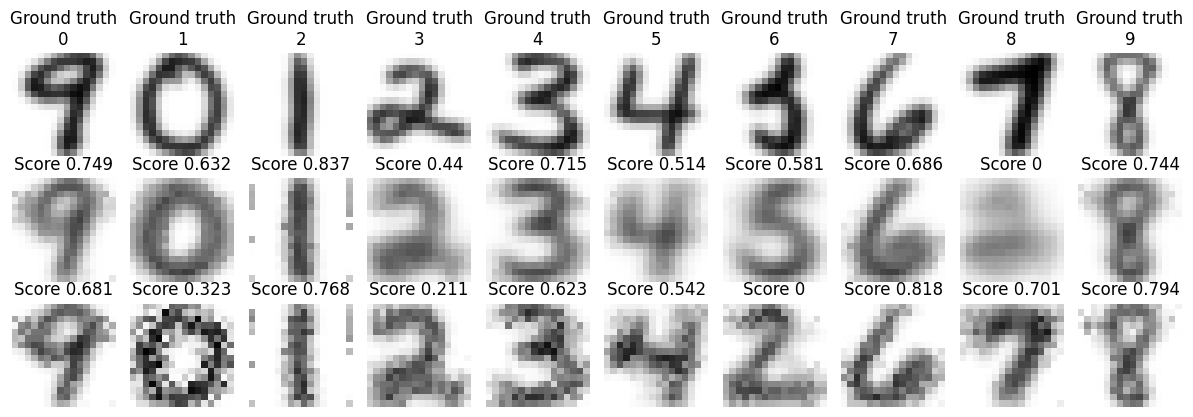

In [4]:
# Compare the final reconstruction scores for every enabled method.
errors = {
    name: reconstruction_error(values.reshape(len(X_test), -1), X_test)
    for name, values in reconstructions.items()
}
score_table = pd.DataFrame({
    "overall score": {name: error["ovr_error"] for name, error in errors.items()},
    "numeric R²": {name: error["num_avg"] for name, error in errors.items()},
})
display(score_table)

if IS_IMAGE:
    reconstruction_scores = {
        name: np.array([
            reconstruction_error(values[i].reshape(-1, 1), X_test[i].reshape(-1, 1))["ovr_error"]
            for i in range(len(X_test))
        ])
        for name, values in reconstructions.items()
    }
    by_class = [np.flatnonzero(y_test == label)[0] for label in np.sort(np.unique(y_test))]
    fig, axes = plt.subplots(1 + len(reconstructions), 10, figsize=(12, 1.4 * (1 + len(reconstructions))), squeeze=False)
    for col, i in enumerate(by_class):
        axes[0, col].imshow(X_test[i].reshape(output_shape), cmap="gray_r", vmin=X.min(), vmax=X.max())
        axes[0, col].set_title(f"Ground truth\n{y_test[i]}")
        axes[0, col].axis("off")
        for row, (name, images) in enumerate(reconstructions.items(), start=1):
            axes[row, col].imshow(images[i], cmap="gray_r", vmin=X.min(), vmax=X.max())
            axes[row, col].set_title(f"Score {reconstruction_scores[name][i]:.3g}")
            axes[row, col].axis("off")
    axes[0, 0].set_ylabel("ground truth")
    for row, name in enumerate(reconstructions, start=1):
        axes[row, 0].set_ylabel(name)
else:
    ax = score_table["overall score"].plot.bar(figsize=(7, 3), rot=25)
    ax.set_ylabel("Reconstruction score")
    ax.set_title("Zilionis reconstruction scores")
plt.tight_layout()
